# Training Log Visualisation

This notebook provides a tool to visualize training logs saved as JSON files. You can select a metric (validation metrics or loss) to plot on the y-axis, with epochs on the x-axis. Each seed run is shown as a separate line with its own color.

In [5]:
import json
import os
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap
from ipywidgets import interact, Dropdown

# Utility to load log JSON

def load_log_json(json_path):
    with open(json_path, 'r') as f:
        return json.load(f)

def extract_metrics(log_data):
    # Returns dict: seed -> {epoch_history: [...], summary: {...}}
    seed_runs = log_data.get('seed_runs', [])
    metrics = {}
    for run in seed_runs:
        seed = run.get('seed', None)
        if seed is not None:
            metrics[seed] = run.get('epoch_history', [])
    return metrics

def get_metric_names(metrics_by_seed):
    # Find all possible metric keys in val_metrics and test_metrics
    metric_names = set(['train_loss'])
    for seed, epochs in metrics_by_seed.items():
        for entry in epochs:
            metric_names.add('train_loss')
            if 'val_metrics' in entry:
                metric_names.update(entry['val_metrics'].keys())
            if 'test_metrics' in entry and entry['test_metrics']:
                metric_names.update(entry['test_metrics'].keys())
    return sorted(metric_names)

def plot_metrics(metrics_by_seed, metric_name):
    plt.figure(figsize=(8,5))
    cmap = get_cmap('tab10')
    for idx, (seed, epochs) in enumerate(metrics_by_seed.items()):
        xs = [e['epoch'] for e in epochs]
        if metric_name == 'train_loss':
            ys = [e['train_loss'] for e in epochs]
        else:
            ys = [e.get('val_metrics', {}).get(metric_name, None) for e in epochs]
        plt.plot(xs, ys, label=f'Seed {seed}', color=cmap(idx))
    plt.xlabel('Epoch')
    plt.ylabel(metric_name)
    plt.title(f'{metric_name} over Epochs')
    plt.legend()
    plt.grid(True)
    plt.show()

def visualize_log(json_path):
    log_data = load_log_json(json_path)
    metrics_by_seed = extract_metrics(log_data)
    metric_names = get_metric_names(metrics_by_seed)
    interact(lambda metric: plot_metrics(metrics_by_seed, metric),
             metric=Dropdown(options=metric_names, value=metric_names[0], description='Metric:'))

visualize_log('/home/gabrimi8/RDL/ReDeLEx/logs/training_logs/rel-f1_driver-position_sage_edge_attr/cfg_1.json')

interactive(children=(Dropdown(description='Metric:', options=('mae', 'mse', 'r2', 'train_loss'), value='mae')…

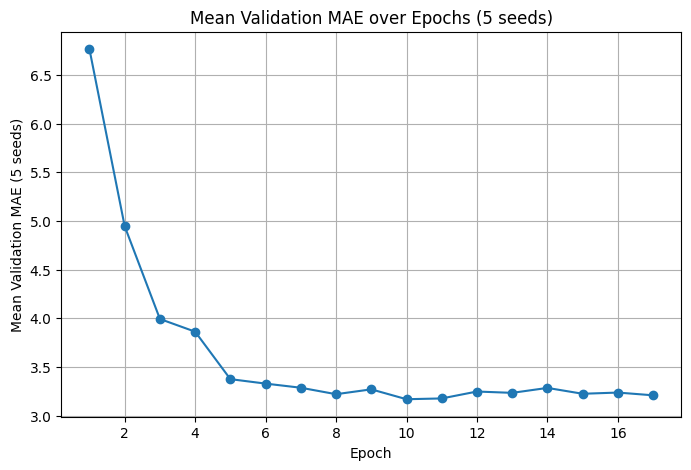

In [11]:
def plot_mean_val_mae(json_path):
    """
    Plots the mean validation MAE over 5 seeds per epoch from a log JSON config.
    y-axis: mean validation_mae, x-axis: epoch number
    """
    import json
    import matplotlib.pyplot as plt
    
    # Load log data
    with open(json_path, 'r') as f:
        log_data = json.load(f)
    
    # Extract per-seed epoch histories
    seed_runs = log_data.get('seed_runs', [])
    if not seed_runs:
        print('No seed_runs found in log.')
        return
    
    # Build epoch -> list of val_mae for all seeds
    epoch_mae = {}
    for run in seed_runs:
        for entry in run.get('epoch_history', []):
            epoch = entry['epoch']
            val_mae = entry.get('val_metrics', {}).get('mae', None)
            if val_mae is not None:
                epoch_mae.setdefault(epoch, []).append(val_mae)
    
    # Calculate mean MAE per epoch
    epochs = sorted(epoch_mae.keys())
    mean_mae = [sum(epoch_mae[e])/len(epoch_mae[e]) for e in epochs]
    
    # Plot
    plt.figure(figsize=(8,5))
    plt.plot(epochs, mean_mae, marker='o')
    plt.xlabel('Epoch')
    plt.ylabel('Mean Validation MAE (5 seeds)')
    plt.title('Mean Validation MAE over Epochs (5 seeds)')
    plt.grid(True)
    plt.show()

In [21]:
import os
import re
def plot_all_configs_mean_val_mae(folder_path, filter_mode=None, benchmark_cfg='cfg_1.json'):
    """
    Plots mean validation MAE over 5 seeds per epoch for all JSON configs in a folder.
    Each config is plotted as a separate line, sorted by number in filename.
    The legend shows process_bridge/hub and bridge/hub strategy parameters from the JSON config (from run_params), without the file name.
    Always plots the benchmark config (default: cfg_1.json) for comparison.
    
    filter_mode: None (all), 'bridge' (only process_bridge True), 'hub' (only process_hub True), 'both' (both True)
    """
    import json
    import matplotlib.pyplot as plt
    
    def extract_number(filename):
        match = re.search(r'(\d+)', filename)
        return int(match.group(1)) if match else float('inf')
    
    config_files = [f for f in os.listdir(folder_path) if f.endswith('.json')]
    config_files.sort(key=extract_number)
    if not config_files:
        print('No JSON config files found in folder.')
        return
    
    plt.figure(figsize=(10,6))
    
    # Always plot benchmark config first (if present)
    plotted_benchmark = False
    if benchmark_cfg in config_files:
        json_path = os.path.join(folder_path, benchmark_cfg)
        with open(json_path, 'r') as f:
            log_data = json.load(f)
        run_params = log_data.get('run_params', {})
        process_bridge = run_params.get('process_bridge', None)
        process_hub = run_params.get('process_hub', None)
        bridge_strategy = run_params.get('bridge_strategy', None)
        hub_strategy = run_params.get('hub_strategy', None)
        seed_runs = log_data.get('seed_runs', [])
        epoch_mae = {}
        for run in seed_runs:
            for entry in run.get('epoch_history', []):
                epoch = entry['epoch']
                val_mae = entry.get('val_metrics', {}).get('mae', None)
                if val_mae is not None:
                    epoch_mae.setdefault(epoch, []).append(val_mae)
        if epoch_mae:
            epochs = sorted(epoch_mae.keys())
            mean_mae = [sum(epoch_mae[e])/len(epoch_mae[e]) for e in epochs]
            legend_label = f"BENCHMARK: bridge_proc={process_bridge}, hub_proc={process_hub}, bridge_strat={bridge_strategy}, hub_strat={hub_strategy}"
            plt.plot(epochs, mean_mae, marker='o', label=legend_label, linewidth=3, color='black')
            plotted_benchmark = True
        config_files = [f for f in config_files if f != benchmark_cfg]
    
    # Plot the rest according to filter
    for cfg in config_files:
        json_path = os.path.join(folder_path, cfg)
        with open(json_path, 'r') as f:
            log_data = json.load(f)
        run_params = log_data.get('run_params', {})
        process_bridge = run_params.get('process_bridge', None)
        process_hub = run_params.get('process_hub', None)
        bridge_strategy = run_params.get('bridge_strategy', None)
        hub_strategy = run_params.get('hub_strategy', None)
        # Filtering logic
        if filter_mode == 'bridge' and not (process_bridge and not process_hub):
            continue
        if filter_mode == 'hub' and not (process_hub and not process_bridge):
            continue
        if filter_mode == 'both' and not (process_bridge and process_hub):
            continue
        seed_runs = log_data.get('seed_runs', [])
        epoch_mae = {}
        for run in seed_runs:
            for entry in run.get('epoch_history', []):
                epoch = entry['epoch']
                val_mae = entry.get('val_metrics', {}).get('mae', None)
                if val_mae is not None:
                    epoch_mae.setdefault(epoch, []).append(val_mae)
        if not epoch_mae:
            continue
        epochs = sorted(epoch_mae.keys())
        mean_mae = [sum(epoch_mae[e])/len(epoch_mae[e]) for e in epochs]
        legend_label = f"bridge_proc={process_bridge}, hub_proc={process_hub}, bridge_strat={bridge_strategy}, hub_strat={hub_strategy}"
        plt.plot(epochs, mean_mae, marker='o', label=legend_label)
    
    plt.xlabel('Epoch')
    plt.ylabel('Mean Validation MAE (5 seeds)')
    plt.title('Mean Validation MAE over Epochs for All Configs')
    plt.legend(fontsize='small')
    plt.grid(True)
    plt.show()

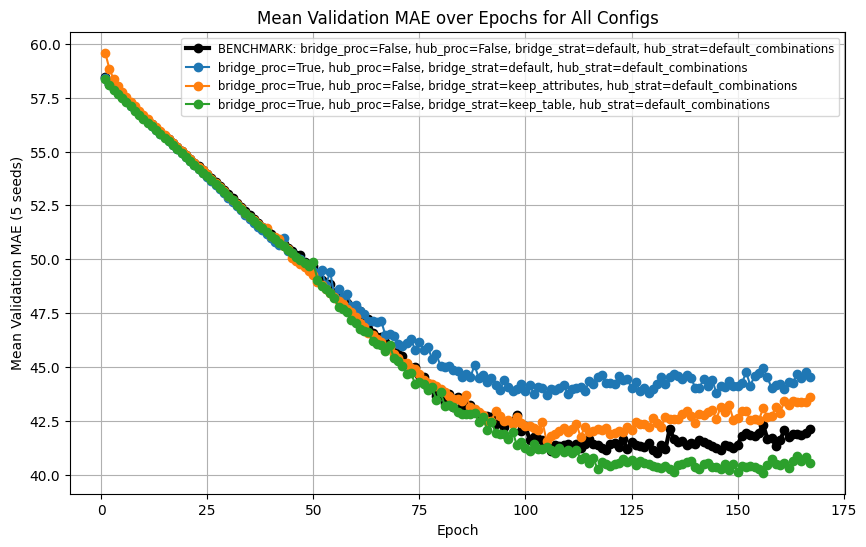

In [51]:
# 'rel-f1_driver-position_sage_edge_attr'
# 'rel-avito_ad-ctr_sage_edge_attr'
# 
# 'rel-trial_study-adverse_sage_edge_attr'

# 'ctu-adventureworks_adventureworks-original_sage_edge_attr'

dataset_name = 'ctu-northwind_northwind-original_sage_edge_attr'
log_name = '/home/gabrimi8/RDL/ReDeLEx/logs/training_logs/'
folder_name = log_name + dataset_name + '/'
plot_all_configs_mean_val_mae(folder_name, filter_mode='bridge')

In [3]:
!ls

__init__.py	      dbgnn_train_25_3_2026.py	  michal.ipynb
dbgnn_hyperparams.py  dbgnn_train_5seedsingle.py  michal_test.ipynb
dbgnn_michal.py       gbdt_hyperparams.py	  tabular_hyperparams.py
dbgnn_train.py	      getml_xgboost.py		  visualise.ipynb


## Usage Instructions

1. Run the code cell above.
2. Call `visualize_log('path/to/your/log.json')` with the path to your log file.
3. Use the dropdown to select which metric to plot (validation metrics or loss).
4. Each seed will be shown as a separate line with its own color.